In [40]:
import json
import subprocess
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

Project root: D:\Skoltech\RL\Projects\Project_2\The-towers-of-Hanoi


In [43]:
LOG_FILES = {
    "REINFORCE 3 disks": PROJECT_ROOT / "logs" / "training_history_reinforce_3_disks_phase1.json",
    "REINFORCE 4 disks": PROJECT_ROOT / "logs" / "training_history_reinforce_4_disks_phase1.json"
}

def load_history(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

histories = {name: load_history(p) for name, p in LOG_FILES.items()}
missing = [n for n, h in histories.items() if h is None]
if missing:
    raise FileNotFoundError(
        "Сначала запустите ячейки обучения. Не найдены: " + ", ".join(missing)
    )

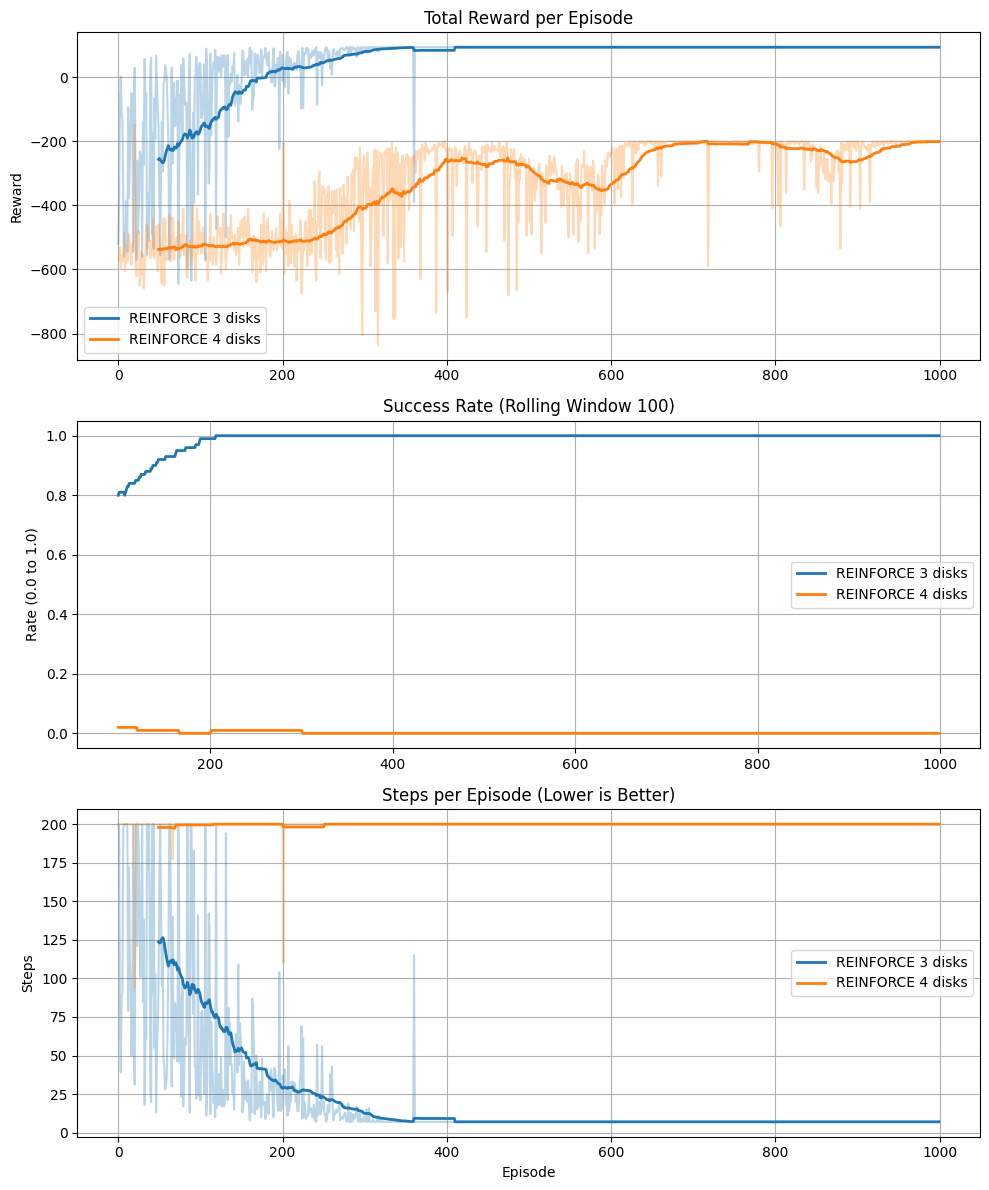

График сохранён: D:\Skoltech\RL\Projects\Project_2\The-towers-of-Hanoi\experiments\training_curves.png


In [44]:
def moving_average(data, window=50):
    """Сглаживание графика для лучшей читаемости (как в plot.py)."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode="valid")

colors = {"REINFORCE 3 disks": "C0", "REINFORCE 4 disks": "C1", "TRPO": "C2"}

# Как в plot.py: 3 графика в столбец
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Total Reward per Episode
for name, history in histories.items():
    if not history:
        continue
    rewards = np.array([h["reward"] for h in history])
    ax1.plot(rewards, alpha=0.3, color=colors[name])
    ma = moving_average(rewards, 50)
    if len(ma) > 0:
        ax1.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax1.set_title("Total Reward per Episode")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# 2. Success Rate (Rolling Window 100)
for name, history in histories.items():
    if not history:
        continue
    success = np.array([h["success"] for h in history], dtype=float)
    success_smooth = moving_average(success, 100)
    if len(success_smooth) > 0:
        ax2.plot(np.arange(99, 99 + len(success_smooth)), success_smooth, color=colors[name], linewidth=2, label=name)
ax2.set_title("Success Rate (Rolling Window 100)")
ax2.set_ylabel("Rate (0.0 to 1.0)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True)

# 3. Steps per Episode (Lower is Better)
for name, history in histories.items():
    if not history:
        continue
    steps = np.array([h["steps"] for h in history])
    ax3.plot(steps, alpha=0.3, color=colors[name])
    ma = moving_average(steps, 50)
    if len(ma) > 0:
        ax3.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax3.set_title("Steps per Episode (Lower is Better)")
ax3.set_ylabel("Steps")
ax3.set_xlabel("Episode")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
out_dir = PROJECT_ROOT / "experiments"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "training_curves.png"
plt.savefig(out_path, dpi=120)
plt.show()
print("График сохранён:", out_path)

In [27]:
LOG_FILES = {
    "random init": PROJECT_ROOT / "logs" / "training_history_reinforce_random_init_phase1.json",
    "random init+high_victory_reward": PROJECT_ROOT / "logs" / "training_history_reinforce_random_init_rew_phase1.json"
}

histories = {name: load_history(p) for name, p in LOG_FILES.items()}
missing = [n for n, h in histories.items() if h is None]
if missing:
    raise FileNotFoundError(
        "Сначала запустите ячейки обучения. Не найдены: " + ", ".join(missing)
    )

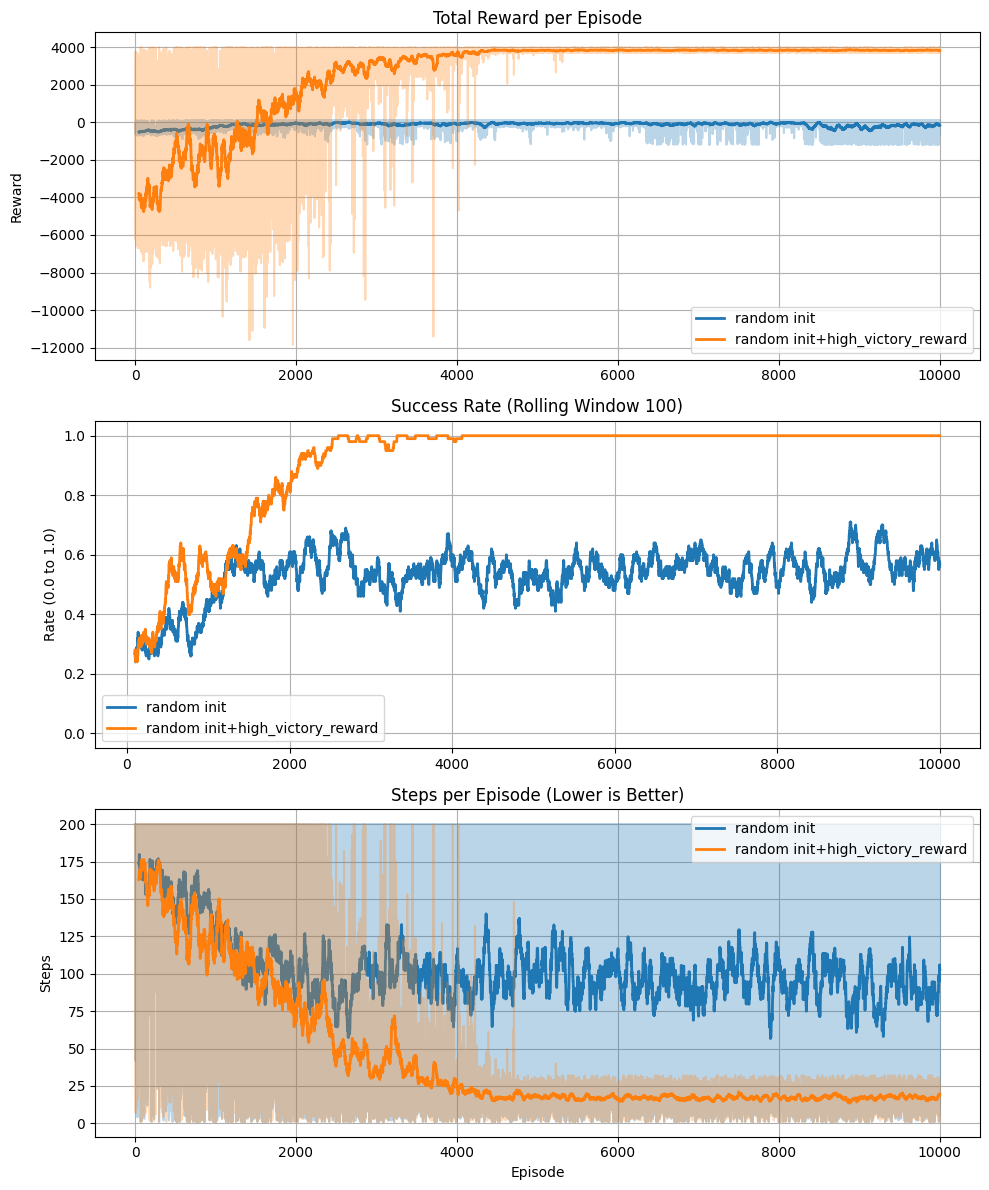

График сохранён: D:\Skoltech\RL\Projects\Project_2\The-towers-of-Hanoi\experiments\training_curves.png


In [28]:
colors = {"random init": "C0", "random init+high_victory_reward": "C1"}

# Как в plot.py: 3 графика в столбец
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Total Reward per Episode
for name, history in histories.items():
    if not history:
        continue
    rewards = np.array([h["reward"] for h in history])
    ax1.plot(rewards, alpha=0.3, color=colors[name])
    ma = moving_average(rewards, 50)
    if len(ma) > 0:
        ax1.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax1.set_title("Total Reward per Episode")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# 2. Success Rate (Rolling Window 100)
for name, history in histories.items():
    if not history:
        continue
    success = np.array([h["success"] for h in history], dtype=float)
    success_smooth = moving_average(success, 100)
    if len(success_smooth) > 0:
        ax2.plot(np.arange(99, 99 + len(success_smooth)), success_smooth, color=colors[name], linewidth=2, label=name)
ax2.set_title("Success Rate (Rolling Window 100)")
ax2.set_ylabel("Rate (0.0 to 1.0)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True)

# 3. Steps per Episode (Lower is Better)
for name, history in histories.items():
    if not history:
        continue
    steps = np.array([h["steps"] for h in history])
    ax3.plot(steps, alpha=0.3, color=colors[name])
    ma = moving_average(steps, 50)
    if len(ma) > 0:
        ax3.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax3.set_title("Steps per Episode (Lower is Better)")
ax3.set_ylabel("Steps")
ax3.set_xlabel("Episode")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
out_dir = PROJECT_ROOT / "experiments"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "training_curves.png"
plt.savefig(out_path, dpi=120)
plt.show()
print("График сохранён:", out_path)

In [37]:
LOG_FILES = {
    "fine-tuning": PROJECT_ROOT / "logs" / "training_history_phase2.json",
}

histories = {name: load_history(p) for name, p in LOG_FILES.items()}
missing = [n for n, h in histories.items() if h is None]
if missing:
    raise FileNotFoundError(
        "Сначала запустите ячейки обучения. Не найдены: " + ", ".join(missing)
    )

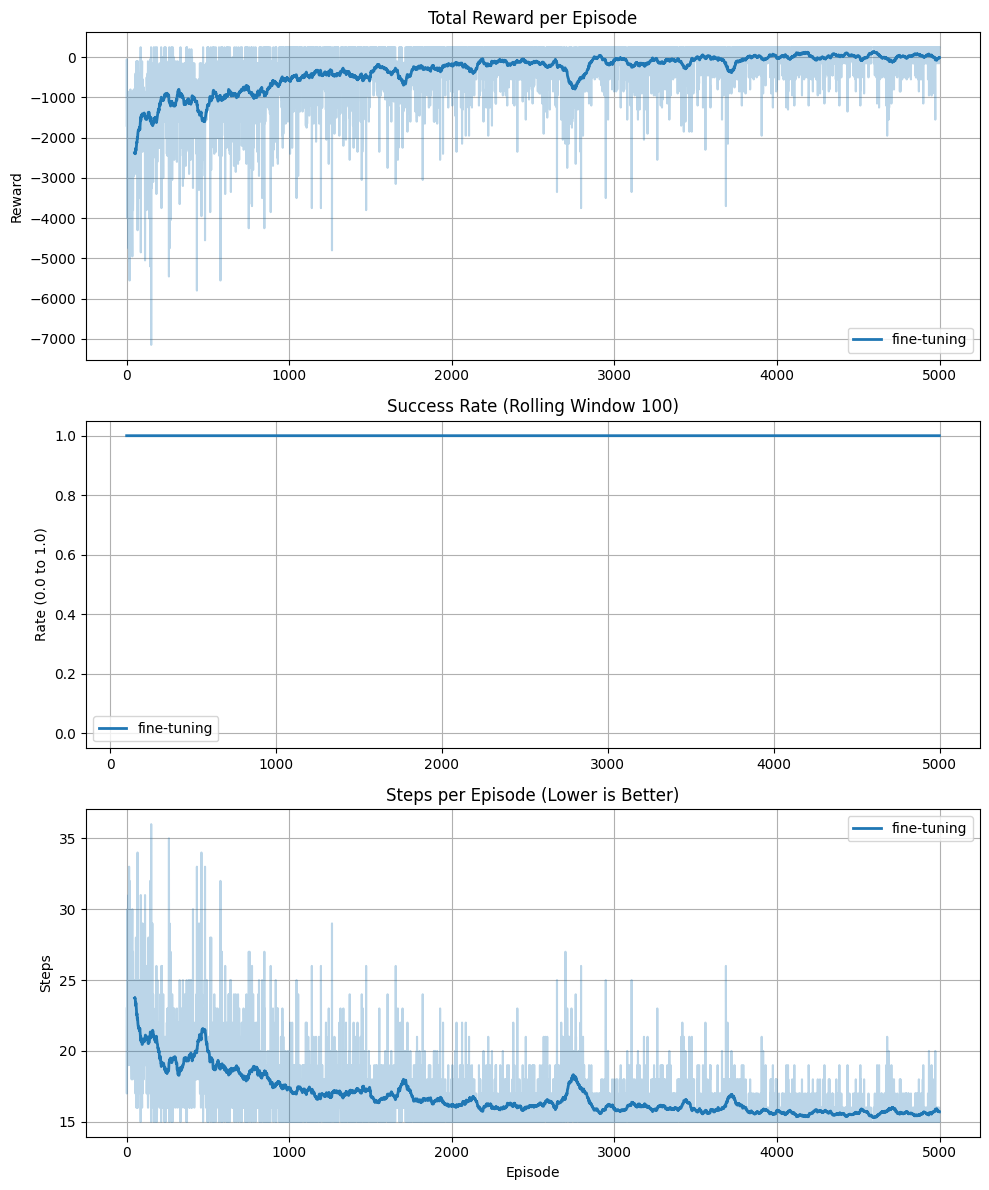

График сохранён: D:\Skoltech\RL\Projects\Project_2\The-towers-of-Hanoi\experiments\training_curves.png


In [38]:
colors = {"fine-tuning": "C0"}

# Как в plot.py: 3 графика в столбец
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Total Reward per Episode
for name, history in histories.items():
    if not history:
        continue
    rewards = np.array([h["reward"] for h in history])
    ax1.plot(rewards, alpha=0.3, color=colors[name])
    ma = moving_average(rewards, 50)
    if len(ma) > 0:
        ax1.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax1.set_title("Total Reward per Episode")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# 2. Success Rate (Rolling Window 100)
for name, history in histories.items():
    if not history:
        continue
    success = np.array([h["success"] for h in history], dtype=float)
    success_smooth = moving_average(success, 100)
    if len(success_smooth) > 0:
        ax2.plot(np.arange(99, 99 + len(success_smooth)), success_smooth, color=colors[name], linewidth=2, label=name)
ax2.set_title("Success Rate (Rolling Window 100)")
ax2.set_ylabel("Rate (0.0 to 1.0)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True)

# 3. Steps per Episode (Lower is Better)
for name, history in histories.items():
    if not history:
        continue
    steps = np.array([h["steps"] for h in history])
    ax3.plot(steps, alpha=0.3, color=colors[name])
    ma = moving_average(steps, 50)
    if len(ma) > 0:
        ax3.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax3.set_title("Steps per Episode (Lower is Better)")
ax3.set_ylabel("Steps")
ax3.set_xlabel("Episode")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
out_dir = PROJECT_ROOT / "experiments"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "training_curves.png"
plt.savefig(out_path, dpi=120)
plt.show()
print("График сохранён:", out_path)